# Imports/Installs

In [1]:
!wget https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
!unzip ne_110m_admin_0_countries.zip

--2026-03-23 18:27:14--  https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
Resolving naturalearth.s3.amazonaws.com (naturalearth.s3.amazonaws.com)... 3.5.76.151, 52.92.250.17, 52.92.209.225, ...
Connecting to naturalearth.s3.amazonaws.com (naturalearth.s3.amazonaws.com)|3.5.76.151|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 214976 (210K) [application/zip]
Saving to: ‘ne_110m_admin_0_countries.zip’

ne_110m_admin_0_cou 100%[===================>] 209.94K  --.-KB/s    in 0.1s    

2026-03-23 18:27:15 (1.62 MB/s) - ‘ne_110m_admin_0_countries.zip’ saved [214976/214976]

Archive:  ne_110m_admin_0_countries.zip
  inflating: ne_110m_admin_0_countries.README.html  
 extracting: ne_110m_admin_0_countries.VERSION.txt  
 extracting: ne_110m_admin_0_countries.cpg  
  inflating: ne_110m_admin_0_countries.dbf  
  inflating: ne_110m_admin_0_countries.prj  
  inflating: ne_110m_admin_0_countries.shp  
  inflating: ne_110m_admin_0_countries.s

In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.covariance import MinCovDet
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import pairwise_distances

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from google.colab import files

from scipy.stats import spearmanr, pearsonr

import shap
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

import geopandas as gpd




# Mounting Google Drive

In [3]:
drive.mount('/content/drive')


Mounted at /content/drive


# Reading in Our Data

This is the data we previously pre-processed in the Coral_EDA.ipynb file.

In [4]:
coral = pd.read_csv("/content/drive/Shareddrives/ML Final Project/Data/coral_df.csv", index_col= 0)

In [5]:
coral.head(10)

,ScientificName,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat,log_depth
0,Stichopathes sp.,18.94637,-155.71550,2002,165.0,19.245,34.881,83.342,2.217484
1,Stichopathes sp.,18.94637,-155.71550,2002,135.0,22.417,35.105,94.884,2.130334
3,Stichopathes sp.,23.26355,-162.99783,2003,364.0,10.695,34.175,73.659,2.561101
4,Stichopathes sp.,23.26355,-162.99783,2003,406.0,10.077,34.133,71.149,2.608526
5,Stichopathes sp.,19.80047,-156.12032,2001,392.0,8.239,34.162,31.779,2.593286
6,Stichopathes sp.,23.26355,-162.99783,2003,362.0,11.453,34.220,75.844,2.558709
7,Stichopathes sp.,21.24882,-158.06667,2004,240.0,14.850,34.526,76.019,2.380211
8,Stichopathes sp.,18.71833,-158.28000,2004,439.0,7.474,34.230,29.589,2.642465
9,Stichopathes sp.,18.71833,-158.28000,2004,409.0,8.356,34.212,47.567,2.611723
10,Stichopathes sp.,18.71833,-158.28000,2004,418.0,7.877,34.225,40.069,2.621176


In [6]:
coral.describe()

,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat,log_depth
count,3138.000000,3138.000000,3138.000000,3138.000000,3138.000000,3138.000000,3138.000000,3138.000000
mean,19.837978,-158.021851,2002.711281,486.394519,8.294872,34.230441,43.779858,2.642649
std,1.528094,2.062172,2.385432,296.931983,2.476199,0.144139,17.551448,0.173946
min,18.708330,-162.997830,2000.000000,59.000000,2.409000,34.065000,9.153000,1.770852
25%,18.732000,-158.262380,2001.000000,384.000000,7.877000,34.162000,31.779000,2.584331
50%,18.968980,-158.259470,2002.000000,398.000000,8.356000,34.206000,47.491000,2.599883
75%,19.808480,-156.121780,2004.000000,424.000000,8.910000,34.225000,54.099000,2.627366
max,23.263550,-155.240850,2007.000000,1771.000000,25.629000,35.105000,104.023000,3.248219


We notice that there are some duplicates (likely as a result of snapping to lat/lon, so we drop those)

In [7]:
coral = coral.drop_duplicates().reset_index(drop=True)

In [8]:
coral.describe()


,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat,log_depth
count,3138.000000,3138.000000,3138.000000,3138.000000,3138.000000,3138.000000,3138.000000,3138.000000
mean,19.837978,-158.021851,2002.711281,486.394519,8.294872,34.230441,43.779858,2.642649
std,1.528094,2.062172,2.385432,296.931983,2.476199,0.144139,17.551448,0.173946
min,18.708330,-162.997830,2000.000000,59.000000,2.409000,34.065000,9.153000,1.770852
25%,18.732000,-158.262380,2001.000000,384.000000,7.877000,34.162000,31.779000,2.584331
50%,18.968980,-158.259470,2002.000000,398.000000,8.356000,34.206000,47.491000,2.599883
75%,19.808480,-156.121780,2004.000000,424.000000,8.910000,34.225000,54.099000,2.627366
max,23.263550,-155.240850,2007.000000,1771.000000,25.629000,35.105000,104.023000,3.248219


Identifying the number of corals per species

In [9]:
coral["ScientificName"].value_counts().head(10)

,count
ScientificName,
Kulamanamana haumeaae,297
Calibelemnon symmetricum,278
Isididae,215
Plexauridae,168
Corallium sp.,160
Primnoidae,132
Corallium regale,125
Antipatharia,123
Keratoisis sp.,70


Only keeping species with over 100 observations to limit noise.

In [10]:
counts = coral["ScientificName"].value_counts()
valid_species = counts[counts >= 100].index
coral = coral[coral["ScientificName"].isin(valid_species)].copy()

In [11]:
coral.describe()

,latitude,longitude,Year,DepthInMeters,temp,salin,ox_sat,log_depth
count,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000,1498.000000
mean,19.758821,-158.158739,2003.037383,431.226302,8.471666,34.202231,45.209677,2.615957
std,1.525399,2.007138,2.571867,182.841022,1.528219,0.093931,15.698209,0.108436
min,18.708330,-162.997830,2000.000000,106.000000,2.475000,34.088000,9.153000,2.025306
25%,18.729000,-158.261880,2001.000000,382.000000,8.239000,34.162000,31.779000,2.582063
50%,18.734200,-158.259470,2002.000000,395.000000,8.356000,34.206000,47.567000,2.596597
75%,19.800470,-156.127250,2004.000000,416.000000,8.910000,34.212000,54.099000,2.619093
max,23.263550,-155.248550,2007.000000,1721.000000,23.529000,35.024000,103.413000,3.235781


# Prep for Models

Defining our features

In [12]:
features = ["temp", "salin", "ox_sat", "log_depth"]


Scaling our features to account for different measurement scales

In [13]:
scaler = StandardScaler()
X_all = scaler.fit_transform(coral[features])

# Model Options and Descriptions

Our goal is to detect coral observations that occur outside their typical environment for that species.

1.   Mahalanobis Distance (baseline): Measures how far each point for each species is from the multivariate mean, accounting for covariance. For example, if temp and depth are correlated (which they are), Mahalonobis will account for this.
2.   Isolation Forest: Randomly partitions feature space for each species and points that get isolated in fewer splits are rare. Rare points get a high anomoly score.
3. One-Class SVM: Leans a boundary of normal data and tags anything outside that boundary as an anomaly.

Mahalonabis is a solid baseline model because it is able to detect points outside the elliptical niche envelope, meaning that it tags coral that are far from the species' central environmental regime.

Isolation forest captures nonlinear gradients and skewed distributions by asking whether points are part of a sparse feature space, meaning that it identifies coral that sit in rarely occupied environmental regions.

One-Class SVM learns curved, nonlinear boundaries and detects anomalies as coral lying outside of those boundaries (for each species).

NOTE: For all three models we must define a tail threshold or percentile that defines the most extreme enviornmental observations. We choose 95% to represent the most extreme observations in environmental feature space.


# Mahalanobis

Computing Mahalanobis per species

In [14]:
coral["mahal_score"] = np.nan

for sp in coral["ScientificName"].unique():

    mask = coral["ScientificName"] == sp

    #extract raw features for this species
    X_sp_raw = coral.loc[mask, features].values

    #standardize within species
    scaler_sp = StandardScaler()
    X_sp = scaler_sp.fit_transform(X_sp_raw)

    #robust covariance estimation
    mcd = MinCovDet(random_state=42, support_fraction=0.75)
    mcd.fit(X_sp)

    #squared Mahalanobis distance
    d2 = mcd.mahalanobis(X_sp)

    coral.loc[mask, "mahal_score"] = d2

Computing percentile ranks for each species

In [15]:
coral["mahal_pct"] = (
    coral.groupby("ScientificName")["mahal_score"]
    .rank(pct=True)
)

Flagging top 5% as anomalies

In [16]:
coral["mahal_anomaly"] = coral["mahal_pct"] >= 0.95

In [17]:
print("Total anomalies:", coral["mahal_anomaly"].sum())

(coral.groupby("ScientificName")["mahal_anomaly"].sum()).sort_values(ascending=False)

Total anomalies: 76


,mahal_anomaly
ScientificName,
Kulamanamana haumeaae,15
Calibelemnon symmetricum,14
Isididae,11
Corallium sp.,9
Plexauridae,8
Primnoidae,7
Corallium regale,6
Antipatharia,6


In [18]:
len(coral)

1498

Visualizing the Anomalies

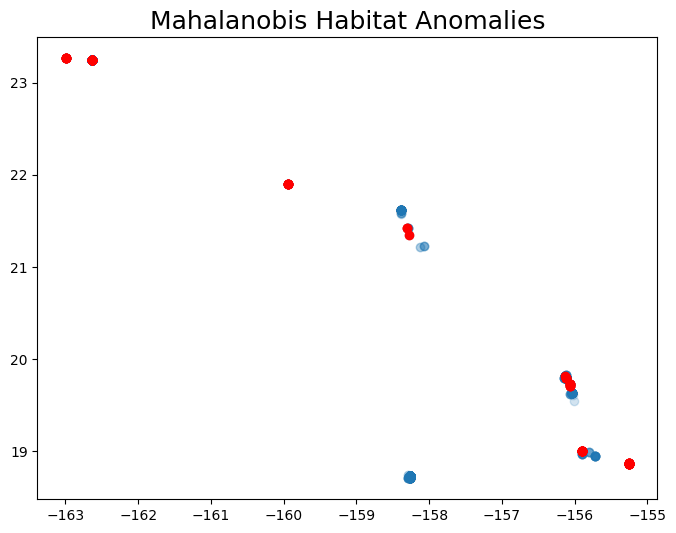

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(coral["longitude"], coral["latitude"], alpha=0.2)
plt.scatter(
    coral.loc[coral["mahal_anomaly"], "longitude"],
    coral.loc[coral["mahal_anomaly"], "latitude"],
    color="red"
)
plt.title("Mahalanobis Habitat Anomalies", fontsize = 18)
plt.show()

# Isolation Forest

In [20]:

#higher score means more anomalous
coral["iso_score"] = np.nan
coral["iso_anomaly"] = False

for sp in coral["ScientificName"].unique():

    mask = coral["ScientificName"] == sp

    #extract raw features
    X_sp_raw = coral.loc[mask, features].values

    #standardize within species
    scaler_sp = StandardScaler()
    X_sp = scaler_sp.fit_transform(X_sp_raw)

    iso = IsolationForest(
        n_estimators=400,
        contamination="auto",
        random_state=42
    )

    iso.fit(X_sp)

    #convert to anomaly score -> higher = more anomalous
    coral.loc[mask, "iso_score"] = -iso.decision_function(X_sp)

#percentile ranking per species
coral["iso_pct"] = coral.groupby("ScientificName")["iso_score"].rank(pct=True)

#top 2.5% per species
coral["iso_anomaly"] = coral["iso_pct"] >= 0.95

Anomalies per species

In [21]:
print("Total anomalies:", coral["iso_anomaly"].sum())
coral.groupby("ScientificName")["iso_anomaly"].sum().sort_values(ascending=False)

Total anomalies: 79


,iso_anomaly
ScientificName,
Kulamanamana haumeaae,15
Calibelemnon symmetricum,14
Isididae,11
Corallium sp.,9
Plexauridae,9
Antipatharia,7
Corallium regale,7
Primnoidae,7


Plotting anomalies

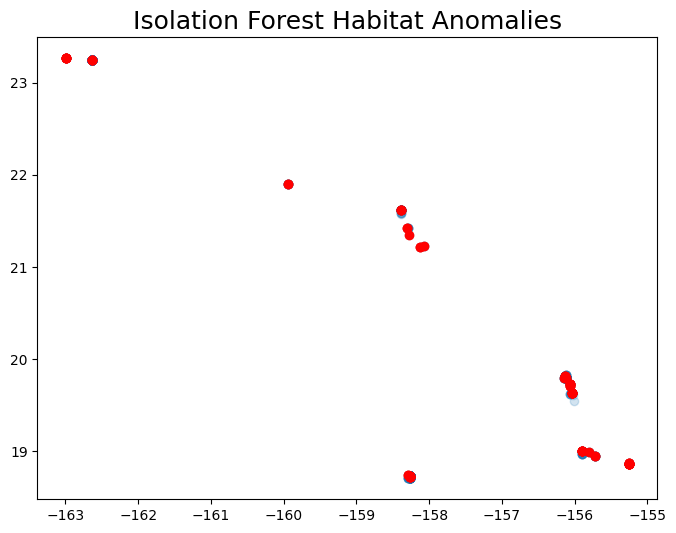

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(coral["longitude"], coral["latitude"], alpha=0.2)
plt.scatter(
    coral.loc[coral["iso_anomaly"], "longitude"],
    coral.loc[coral["iso_anomaly"], "latitude"],
    color="red"
)
plt.title("Isolation Forest Habitat Anomalies", fontsize = 18)
plt.show()

# SVM

In [23]:


cutoff = 0.95

coral = coral.copy()
#higher score means more anomalous
coral["ocsvm_score"] = np.nan
coral["ocsvm_pct"] = np.nan
coral["ocsvm_anomaly"] = False

#starting hyperparameters

#expected anomaly fraction
nu = 0.1
#controls kernel width, scale is a good default
gamma = "scale"

for sp in coral["ScientificName"].unique():
    mask = coral["ScientificName"] == sp
    X_sp_raw = coral.loc[mask, features].values

    #standardizing within species
    X_sp = StandardScaler().fit_transform(X_sp_raw)

    oc = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
    oc.fit(X_sp)

    #decision_function -> positive for inliers, negative for outliers
    #Convert to anomaly score where higher is more anomalous
    scores = -oc.decision_function(X_sp).ravel()

    coral.loc[mask, "ocsvm_score"] = scores
    coral.loc[mask, "ocsvm_pct"] = pd.Series(scores, index=coral.index[mask]).rank(pct=True)

coral["ocsvm_anomaly"] = coral["ocsvm_pct"] >= cutoff

print("Total One-Class SVM anomalies:", coral["ocsvm_anomaly"].sum())
print("\nAnomalies per species:")
print(coral.groupby("ScientificName")["ocsvm_anomaly"].sum().sort_values(ascending=False))





Total One-Class SVM anomalies: 80

Anomalies per species:
ScientificName
Kulamanamana haumeaae       15
Calibelemnon symmetricum    14
Isididae                    11
Corallium sp.                9
Plexauridae                  9
Corallium regale             8
Antipatharia                 7
Primnoidae                   7
Name: ocsvm_anomaly, dtype: int64


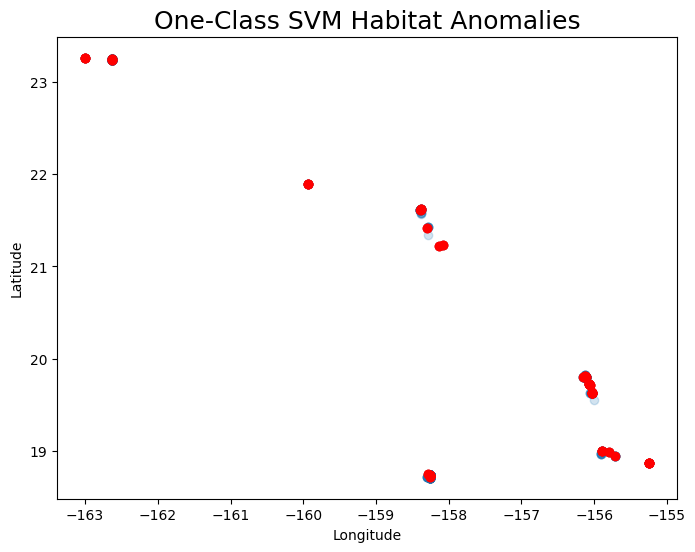

In [24]:
#plotting anomalies
plt.figure(figsize=(8,6))
plt.scatter(coral["longitude"], coral["latitude"], alpha=0.2)
plt.scatter(
    coral.loc[coral["ocsvm_anomaly"], "longitude"],
    coral.loc[coral["ocsvm_anomaly"], "latitude"],
    color="red"
)
plt.title("One-Class SVM Habitat Anomalies", fontsize = 18)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Computing Model Agreement

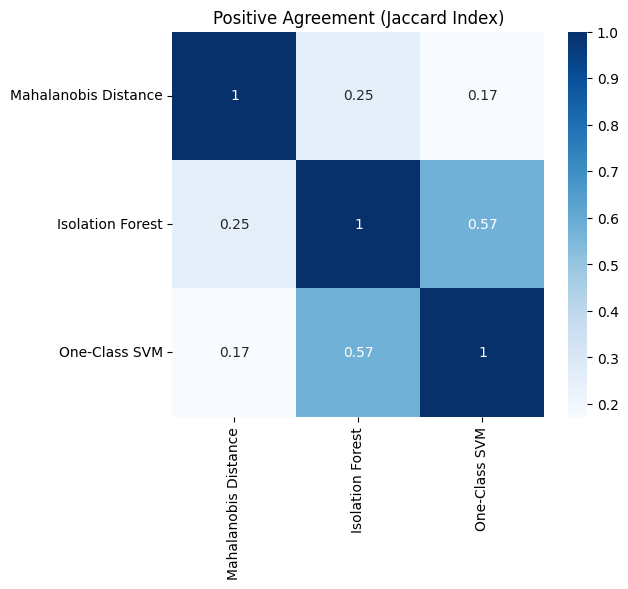

In [25]:
models = ["mahal_anomaly", "iso_anomaly", "ocsvm_anomaly"]

positive_agreement = pd.DataFrame(index=models, columns=models)

#computing jaccard agreement for each model
for m1 in models:
    for m2 in models:
        both_positive = (coral[m1] & coral[m2]).sum()
        either_positive = (coral[m1] | coral[m2]).sum()
        positive_agreement.loc[m1, m2] = both_positive / either_positive

positive_agreement = positive_agreement.astype(float)
positive_agreement

# Rename for cleaner visualization
label_map = {
    "mahal_anomaly": "Mahalanobis Distance",
    "iso_anomaly": "Isolation Forest",
    "ocsvm_anomaly": "One-Class SVM"
}

positive_agreement = positive_agreement.rename(index=label_map, columns=label_map)
#making a heatmap for model agreement
plt.figure(figsize=(6,5))
sns.heatmap(positive_agreement, annot=True, cmap="Blues")
plt.title("Positive Agreement (Jaccard Index)")
plt.show()

In [26]:
(coral["mahal_anomaly"] &
 coral["iso_anomaly"] &
 coral["ocsvm_anomaly"]).sum()

np.int64(19)

We notice that ISO and OCSVM agree fairly strong (.57%), suggesting that anomalies are boundary/sparsity driven, not purely distance driven.

# Iso and SVM - High Confidence

In [27]:
coral["high_conf_anomaly"] = (
    coral["ocsvm_anomaly"] &
    coral["iso_anomaly"])

print("High confidence:", coral["high_conf_anomaly"].sum())


High confidence: 58


# Comparing Environmental Distributions

In [28]:
#anomaly rate per species
(
    coral
    .groupby("ScientificName")["high_conf_anomaly"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

,high_conf_anomaly
ScientificName,
Antipatharia,4.878049
Corallium regale,4.800000
Primnoidae,4.545455
Corallium sp.,4.375000
Calibelemnon symmetricum,3.956835
Kulamanamana haumeaae,3.703704
Plexauridae,3.571429
Isididae,2.325581


In [29]:
#environmental shift per species
for sp in coral["ScientificName"].unique():
    sub = coral[coral["ScientificName"] == sp]
    normal = sub[~sub["high_conf_anomaly"]]
    anomaly = sub[sub["high_conf_anomaly"]]

    if len(anomaly) > 0:
        print("\n", sp)
        for var in features:
            shift = anomaly[var].mean() - normal[var].mean()
            print(var, "shift:", round(shift,3))


 Calibelemnon symmetricum
temp shift: -1.655
salin shift: 0.104
ox_sat shift: -11.63
log_depth shift: 0.184

 Corallium sp.
temp shift: 2.267
salin shift: 0.154
ox_sat shift: 7.158
log_depth shift: -0.04

 Corallium regale
temp shift: 1.694
salin shift: 0.003
ox_sat shift: 12.961
log_depth shift: -0.066

 Plexauridae
temp shift: -4.192
salin shift: 0.228
ox_sat shift: -30.037
log_depth shift: 0.385

 Primnoidae
temp shift: -0.267
salin shift: 0.28
ox_sat shift: -13.275
log_depth shift: 0.129

 Kulamanamana haumeaae
temp shift: -0.123
salin shift: -0.026
ox_sat shift: -1.236
log_depth shift: 0.029

 Antipatharia
temp shift: 7.122
salin shift: 0.644
ox_sat shift: 20.482
log_depth shift: -0.201

 Isididae
temp shift: -1.867
salin shift: 0.169
ox_sat shift: -21.302
log_depth shift: 0.178


There appear to be two distinct anomaly regimes:

1: deep/cold/low-oxygen/high salinity: Calibelemnon symmetricum, pledauridae, isididae, primnoidae

2: warm/high oxygen/more shallow: antipartharia, corallium sp., corallium regalae, kulamanamana haumeaae

The deep group signifies niche boundary behavior near low-oxygen and intermediate/deep water masses

The warmer group is a warm-edge signature.

# Anomaly Rate vs. Features

In [32]:
for var in features:
    pearson_corr, pearson_p = pearsonr(coral[var], coral["high_conf_anomaly"])
    spearman_corr, spearman_p = spearmanr(coral[var], coral["high_conf_anomaly"])

    print(f"\n{var}")
    print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.4f}")
    print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.4f}")


temp
Pearson r = 0.027, p = 0.3038
Spearman rho = -0.039, p = 0.1290

salin
Pearson r = 0.343, p = 0.0000
Spearman rho = 0.113, p = 0.0000

ox_sat
Pearson r = -0.059, p = 0.0233
Spearman rho = -0.075, p = 0.0036

log_depth
Pearson r = 0.138, p = 0.0000
Spearman rho = 0.061, p = 0.0184


By computing the correlation between our features and the anomaly counts, we see that anomaly counts increase with decreasing temp and oxygen saturation. They increase with increasing salinity and depth. Depth and salinity show the highest correlations

Let's plot anomaly rate vs. depth and salinity.

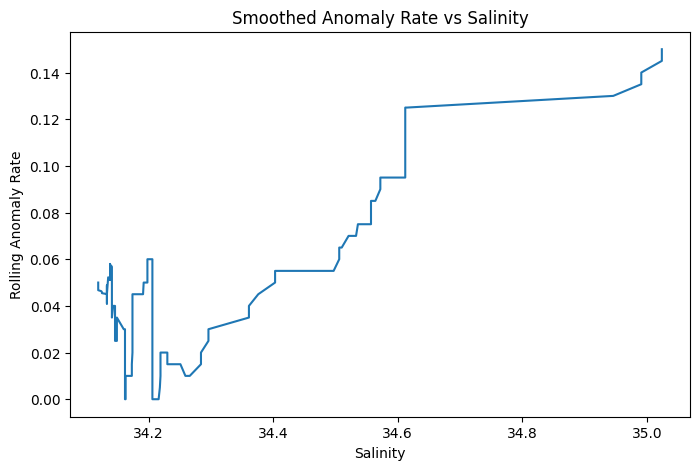

In [33]:
coral_sorted = coral.sort_values("salin").reset_index(drop=True)

rolling_rate = (
    coral_sorted["high_conf_anomaly"]
    .rolling(200, min_periods=100)
    .mean()
)

plt.figure(figsize=(8,5))
plt.plot(coral_sorted["salin"], rolling_rate)
plt.xlabel("Salinity")
plt.ylabel("Rolling Anomaly Rate")
plt.title("Smoothed Anomaly Rate vs Salinity")
plt.show()

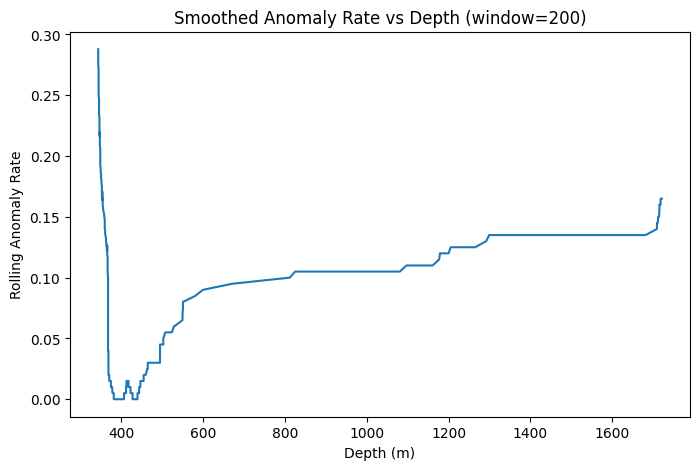

In [34]:
#sort by depth
coral_sorted = coral.sort_values("DepthInMeters").reset_index(drop=True)

#window size
window = 200

rolling_rate = (
    coral_sorted["high_conf_anomaly"]
    .rolling(window=window, min_periods=window//3)
    .mean()
)

plt.figure(figsize=(8,5))
plt.plot(coral_sorted["DepthInMeters"], rolling_rate)
plt.xlabel("Depth (m)")
plt.ylabel("Rolling Anomaly Rate")
plt.title(f"Smoothed Anomaly Rate vs Depth (window={window})")
plt.show()

Transition zones in depth and salinity may imply water mass boundaries.

# Next Steps

What we have produced above is a framework to detect anomalous corals given enviornmental conditions. As all of our enviornmental data was aggregated over multiple decades, we were not able to determine any climate-change dependence. With more data in the future, this model could be applied to track anomalies over time and identify possible danger zones for corals.